In [4]:
%pip install  matplotlib
%pip install  seaborn

  Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.11.0-cp312-cp312-win_amd64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Understanding

In [8]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\mainu\Desktop\NB_Project\spam.csv",
    encoding="latin1"
)

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
df.shape

(5572, 5)

In [10]:
df.dtypes

v1            str
v2            str
Unnamed: 2    str
Unnamed: 3    str
Unnamed: 4    str
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [12]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(403)

# Observation - Dataset Understanding

- The dataset contains 5572 SMS messages and 5 columns.
- The target variable is v1, which contains the labels ham and spam.
- The message content is stored in v2.
- Columns Unnamed: 2, Unnamed: 3, and Unnamed: 4 contain a large number of missing values.
- No missing values are present in the main columns (v1 and v2).
- The dataset consists entirely of text/categorical data.
- The unnamed columns do not contribute to spam classification and will be removed

In [14]:
df["v1"].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

# Observation - Class Distribution

 - The dataset contains 4825 Ham messages and 747 Spam messages.
- Ham messages represent the majority class in the dataset.
- Spam messages are significantly fewer than Ham messages.


# Data Cleaning


In [15]:
# Drop unwanted columns

df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"])

# Rename columns

df.columns = ["label", "message"]

# Check duplicate records

print("Duplicates Before Removal:", df.duplicated().sum())

# Remove duplicates

df = df.drop_duplicates()

# Verify duplicates

print("Duplicates After Removal:", df.duplicated().sum())

# Final shape

print("Dataset Shape:", df.shape)

# Display first few records

df.head()

Duplicates Before Removal: 403
Duplicates After Removal: 0
Dataset Shape: (5169, 2)


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


# Observation
- Removed 3 unnecessary columns containing mostly missing values.
- Renamed columns from v1 and v2 to label and message for better readability.
- Found 403 duplicate records in the dataset.
- Removed all duplicate records successfully.
- Dataset size reduced from 5572 records to 5169 records.
- No duplicate records remain in the cleaned dataset.
- The dataset is now ready for feature engineering and further analysis

# Visualize Class Distribution

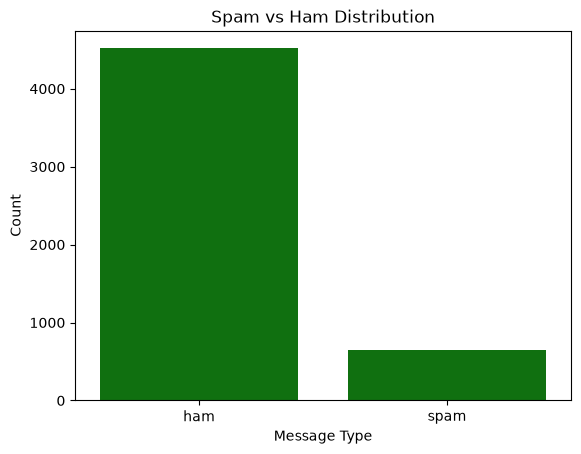

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="label", data=df,color="green")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

# Observation - Spam vs Ham Distribution Plot

- The majority of messages belong to the Ham class.
- Spam messages are significantly fewer than Ham messages.
- The visualization confirms that the dataset is imbalanced.
- Approximately 86.6% of the messages are Ham and 13.4% are Spam.
- This imbalance should be considered during model evaluation.
- Metrics such as Precision, Recall, and F1-Score will be important in addition to Accuracy.

In [17]:
# Message Length Feature
df["message_length"] = df["message"].apply(len)
df["message_length"].describe()

count    5169.000000
mean       78.977945
std        58.236293
min         2.000000
25%        36.000000
50%        60.000000
75%       117.000000
max       910.000000
Name: message_length, dtype: float64

# Observation
- The average message length is approximately 79 characters.
- The shortest message contains 2 characters.
- The longest message contains 910 characters.
- 50% of the messages have a length of 60 characters or less.
- Most messages are relatively short, while a few messages are very long.
- The large difference between the minimum and maximum values suggests the presence of potential outliers.
- Message length may be a useful feature for distinguishing between Spam and Ham messages.
Next: Messag

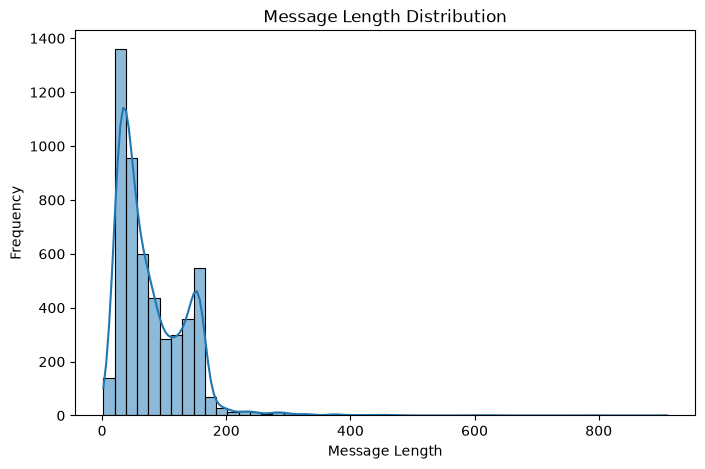

In [18]:
# Message Length Distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df["message_length"], bins=50, kde=True)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()

# Observation
- The distribution of message lengths is right-skewed.
- Most messages have lengths between 20 and 150 characters.
- A small number of messages have very large lengths, creating a long right tail.
- The histogram indicates the presence of potential outliers.
- Short and medium-length messages are more common than very long messages.
- Message length appears to be a useful feature for spam detection.

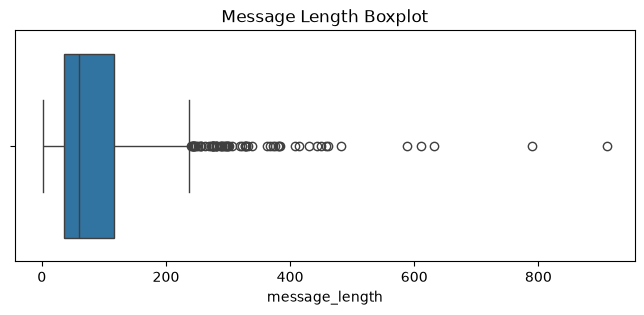

In [19]:
# Boxplot for Outlier Analysis
plt.figure(figsize=(8,3))
sns.boxplot(x=df["message_length"])
plt.title("Message Length Boxplot")
plt.show()

# Observation
- The boxplot shows several outliers on the higher side of message length.
- Most messages have lengths below 250 characters.
- A few messages have very large lengths, extending beyond 900 characters.
- These outliers represent unusually long messages.
- Since message length is an important feature for spam detection, the outliers will be retained.
- Removing these outliers may lead to loss of useful information.

**Decision:**

- Outliers will not be removed.
- Message length outliers may help the Naive Bayes model distinguish Spam from Ham messages more effectively.

# Feature Engineering

In [20]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mainu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [21]:
from nltk.tokenize import sent_tokenize

# Number of words
df["word_count"] = df["message"].apply(lambda x: len(x.split()))

# Number of characters
df["char_count"] = df["message"].apply(len)

# Number of sentences
df["sentence_count"] = df["message"].apply(lambda x: len(sent_tokenize(x)))

df[["message_length","word_count","char_count","sentence_count"]].head()

,message_length,word_count,char_count,sentence_count
0,111,20,111,2
1,29,6,29,2
2,155,28,155,2
3,49,11,49,1
4,61,13,61,1


# Observation
- Created four numerical features from the message text.
- message_length stores the total length of each message.
- word_count stores the total number of words in each message.
- char_count stores the total number of characters in each message.
- sentence_count stores the total number of sentences in each message.
- These features may help identify differences between Spam and Ham messages.
- Longer messages often contain more words and characters, which can be useful for classification.

# Statistics Summary

In [22]:
df[["message_length","word_count","char_count","sentence_count"]].describe()

,message_length,word_count,char_count,sentence_count
count,5169.000000,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,78.977945,1.965564
std,58.236293,11.068488,58.236293,1.448541
min,2.000000,1.000000,2.000000,1.000000
25%,36.000000,7.000000,36.000000,1.000000
50%,60.000000,12.000000,60.000000,1.000000
75%,117.000000,22.000000,117.000000,2.000000
max,910.000000,171.000000,910.000000,38.000000


# Observation
- Average message length is 79 characters.
- Average message contains 15 words.
- Most messages contain 1 to 2 sentences.
- Most messages are short in length.
- A few messages are very long compared to the rest.
- Some outliers are present in the dataset.
- These features may help in identifying Spam and Ham message

# Correlation Heatmap

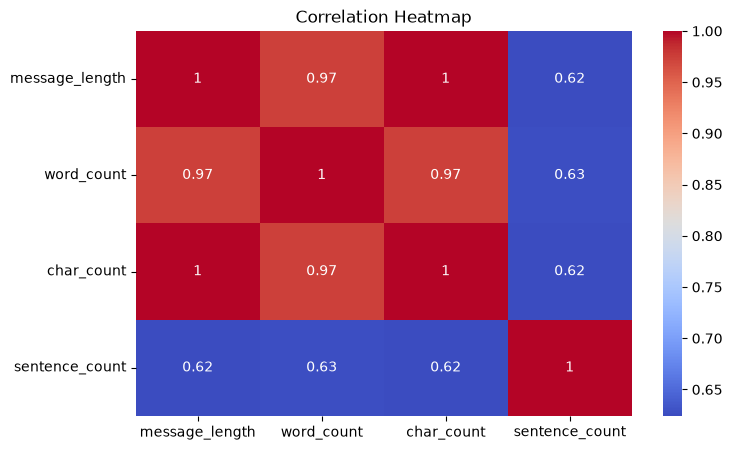

In [23]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[["message_length","word_count","char_count","sentence_count"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# Observation
- Message length and character count are perfectly correlated.
- Word count is strongly correlated with message length and character count.
- Sentence count has a moderate positive correlation with other features.
- As message length increases, word count also increases.
- These features are useful for understanding message characteristics.

In [24]:
df.groupby("label")[["message_length","word_count","sentence_count"]].mean()

,message_length,word_count,sentence_count
label,,,
ham,70.459256,14.134632,1.820195
spam,137.891271,23.681470,2.970904


- Spam messages are longer than Ham messages.
- Spam messages contain more words than Ham messages.
- Spam messages contain more sentences than Ham messages.
- Spam messages generally have more content compared to Ham messages.
- Message length, word count, and sentence count can help distinguish Spam from Ham messages.

# Text Preprocessing

In [25]:
import nltk
import string

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mainu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mainu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
def transform_text(text):

    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

In [27]:
df["transformed_message"] = df["message"].apply(transform_text)

df[["message","transformed_message"]].head()

,message,transformed_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


# Observation
- Converted all messages to lowercase.
- Removed punctuation and special characters.
- Removed common stopwords.
- Applied stemming to reduce words to their root form.
- Cleaned text is shorter and more meaningful.
- The processed text is ready for TF-IDF vectorization.

# Label Encoding

In [28]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["label"])
df.head()

,label,message,message_length,word_count,char_count,sentence_count,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,20,111,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,6,29,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,155,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,11,49,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,61,1,nah think goe usf live around though


- Converted Ham and Spam labels into numerical values.
- Ham is encoded as 0.
- Spam is encoded as 1.
- Numerical labels are required for machine learning models.

In [29]:
X = df[
    [
        "transformed_message",
        "message_length",
        "word_count",
        "char_count",
        "sentence_count"
    ]
]

y = df["label"]
print(type(X))

<class 'pandas.DataFrame'>


# Train Test Split

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4135, 5)
(1034, 5)
(4135,)
(1034,)


- The training set contains 4135 messages.
- The testing set contains 1034 messages.
- Each message is represented by 3000 TF-IDF features.
- Most of the data is used for training the model.
- The test set will be used to evaluate model performance on unseen messages.

In [31]:
print(type(X_train))
print(X_train.head())

<class 'pandas.DataFrame'>
                                    transformed_message  message_length  \
2228                                       exact intent              30   
5529                                                one              25   
2149                         waaaat lololo ok next time              34   
5058  free video camera phone half price line rental...             145   
5051  tick tick tick could die loneli know pout stom...             111   

      word_count  char_count  sentence_count  
2228           5          30               1  
5529           5          25               1  
2149           6          34               2  
5058          24         145               2  
5051          23         111               3  


# Column Transformer

In [32]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("text",
         TfidfVectorizer(max_features=3000),
         "transformed_message"),

        ("num",
         MinMaxScaler(),
         ["message_length",
          "word_count",
          "char_count",
          "sentence_count"])
    ]
)

**Observation:**

- TF-IDF is applied to the text feature (transformed_message).
- MinMaxScaler is applied to numerical features.
- Text and numerical features are processed separately.
- ColumnTransformer combines different preprocessing techniques into a single step.

In [33]:
# Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    preprocessor,
    MultinomialNB()
)

model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=3000),
                                                  'transformed_message'),
                                                 ('num', MinMaxScaler(),
                                                  ['message_length',
                                                   'word_count', 'char_count',
                                                   'sentence_count'])])),
                ('multinomialnb', MultinomialNB())])

# Model Training

In [34]:
# Train the Model
model.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=3000),
                                                  'transformed_message'),
                                                 ('num', MinMaxScaler(),
                                                  ['message_length',
                                                   'word_count', 'char_count',
                                                   'sentence_count'])])),
                ('multinomialnb', MultinomialNB())])

- ColumnTransformer successfully processed text and numerical features.
- TF-IDF converted text messages into numerical vectors.
- MinMaxScaler scaled the numerical features.
- Multinomial Naive Bayes was trained on the processed data.
- The pipeline combines preprocessing and model training into a single workflow.

# Prediction

In [35]:
y_pred = model.predict(X_test)
y_pred[:10]

array([0, 0, 0, 0, 0, 1, 0, 1, 0, 0])

# Evaluation Metrics

In [36]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.9680851063829787
Precision: 0.9912280701754386
Recall   : 0.7793103448275862
F1 Score : 0.8725868725868726


- The model achieved an accuracy of 96.81%.
- Precision is 99.12%, indicating very few ham messages were incorrectly classified as spam.
- Recall is 77.93%, meaning most spam messages were correctly identified.
- F1 Score is 87.26%, showing a good balance between precision and recall.
- The model performs very well for spam classification.

In [37]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[888   1]
 [ 32 113]]


- Correctly classified 888 ham messages.
- Incorrectly classified only 1 ham message as spam.
- Correctly classified 113 spam messages.
- Missed 32 spam messages.
- The model has very low false positives, which is desirable in spam detection.

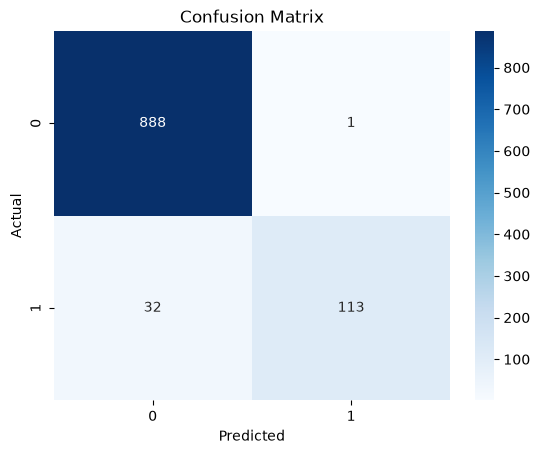

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Final Conclusion

- Data cleaning and preprocessing were successfully performed.
- Feature engineering was applied using message length, word count, character count, and sentence count.
- TF-IDF was used to convert text into numerical features.
- ColumnTransformer was used to preprocess text and numerical features separately.
- make_pipeline combined preprocessing and model training into a single workflow.
- Multinomial Naive Bayes was chosen because it is well-suited for TF-IDF based text classification.
- The final model achieved 96.81% accuracy with 99.12% precision.
- The model can effectively classify SMS messages as Spam or Ham.

# Save the Model

In [39]:
import pickle

with open("spam_classifier.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


# The complete pipeline has been saved as a .pkl file.
The saved model includes:
- TF-IDF Vectorizer
- MinMaxScaler
- ColumnTransformer
- Multinomial Naive Bayes
- The model is ready for deployment in Streamlit

In [41]:
import os

print(os.listdir())

['.venv', 'app.py', 'requirements.txt', 'spam.csv', 'spam_classifier.pkl', 'Spam_Ham__Classification.ipynb']


In [42]:
import joblib

model = joblib.load("spam_classifier.pkl")

In [43]:
import os
print(os.listdir())

['.venv', 'app.py', 'requirements.txt', 'spam.csv', 'spam_classifier.pkl', 'Spam_Ham__Classification.ipynb']


In [52]:
import joblib

joblib.dump(model, "spam_classifier.pkl")

['spam_classifier.pkl']

In [48]:
import pandas as pd
import joblib

model = joblib.load("spam_classifier.pkl")

sample = pd.DataFrame({
    "transformed_message": ["free iphone winner"],
    "message_length": [18],
    "word_count": [3],
    "char_count": [18],
    "sentence_count": [1]
})

print(model.predict(sample))

[1]


In [50]:
print(df['label'].unique())
print(encoder.classes_)

[0 1]
['ham' 'spam']


In [53]:
import os
print(os.path.getsize("spam_classifier.pkl"))

204809
